# ⚡ UltraGPT — Build, Train & Deploy a Modern LLM from Scratch

A production-grade decoder-only Transformer incorporating **RoPE**, **Grouped-Query Attention**, **RMSNorm**, and **SwiGLU** — the same building blocks used in LLaMA 3, Mistral, and Claude 3.

---

### Notebook Outline

| Phase | Section | Description |
|-------|---------|-------------|
| **Setup** | §0 | Imports, config, environment check |
| **Phase 1** | §1 | Data pipeline — text, TFRecords, HuggingFace |
| **Phase 2** | §2 | Custom layers — RMSNorm, RoPE, GQA, SwiGLU |
| **Phase 3** | §3 | Model assembly, causal masking, training |
| **Phase 4** | §4 | Inference — KV-cache, XLA, sampling strategies |

---
## §0 — Setup & Environment

In [129]:
# Install dependencies (uncomment if not already installed)
# !pip install -r requirements.txt

In [130]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure project root is importable
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Project modules
from config import UltraGPTConfig, toy_config, small_config, medium_config
from models.layers.rmsnorm import RMSNorm
from models.layers.rope import RotaryPositionEmbedding, apply_rope
from models.layers.attention import GroupedQueryAttention
from models.layers.swiglu import SwiGLU
from models.transformer import DecoderBlock, UltraGPT
from models.loss import causal_lm_loss, PerplexityMetric
from data_pipeline.pipeline import (
    TiktokenWrapper,
    create_dataset_from_text,
    create_dataset_from_generator,
    create_dataset_from_hf,
    write_tfrecords,
    create_dataset_from_tfrecords,
)
from inference.sampler import UltraGPTSampler

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.16.1
GPU available: []
NumPy version: 1.26.4


In [131]:
config = UltraGPTConfig(
    batch_size=3,

    # Architecture
    d_model=500,
    n_heads=10,
    n_kv_heads=2,
    n_layers=6,
    block_size=128,
    dropout_rate=0.05,     # Very low — let the model memorize the small dataset

    # Training
    learning_rate=3e-4,    # Lower LR → smoother convergence, better accuracy
    warmup_steps=200,      # Longer warmup → stable early training
    max_steps=5000,        # More steps → fully learn dataset patterns
    weight_decay=0.01,

    # Inference (for accurate, prompt-matching output)
    temperature=0.3,       # Low → picks the most likely next token
    top_k=5,               # Tiny pool → sticks to learned patterns
    top_p=0.85,            # Slightly tighter nucleus sampling
    max_gen_length=128,
)


---
## §1 — Phase 1: High-Performance Data Pipeline

The data pipeline supports three ingestion modes:

| Mode | Best For | Throughput |
|------|----------|------------|
| **Raw text** | Quick experiments, small files | Good |
| **TFRecords** | Production training, large corpora | Maximum |
| **HuggingFace** | Any Hub dataset, streaming large corpora | Good (streaming) |

### 1.1 — Tokenizer

In [132]:
# Initialize the tiktoken tokenizer (GPT-2 BPE, 50257 tokens)
tokenizer = TiktokenWrapper(encoding_name="r50k_base")

# Demo encode/decode
sample_text = "UltraGPT is a modern Transformer built from scratch."
token_ids = tokenizer.encode(sample_text)
decoded = tokenizer.decode(token_ids)

print(f"Text:       {sample_text}")
print(f"Token IDs:  {token_ids}")
print(f"Num tokens: {len(token_ids)}")
print(f"Decoded:    {decoded}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token:  {tokenizer.eos_token_id}")

Text:       UltraGPT is a modern Transformer built from scratch.
Token IDs:  [36122, 38, 11571, 318, 257, 3660, 3602, 16354, 3170, 422, 12692, 13]
Num tokens: 12
Decoded:    UltraGPT is a modern Transformer built from scratch.
Vocab size: 50257
EOS token:  50256


### 1.2 — Niche Web Scraper (Custom Dataset Gathering)

To train your model on a specific topic, you can scrape relevant articles from Wikipedia or other web pages using the new `data_pipeline/scraper.py` pipeline. It cleans citation tags, filters out metadata/scripts, and saves raw text directly into a compatible format.

In [133]:
# import os
# # Import the scraping module
# from data_pipeline import scrape_wikipedia_niche, scrape_url

# # Scenario A: Scrape a niche topic from Wikipedia
# niche_topic = "python"
# print(f"Scraping top Wikipedia articles for: '{niche_topic}'...")
# scraped_text = scrape_wikipedia_niche(query=niche_topic, limit=2)

# # Preview first 500 characters of the scraped corpus
# print("\n--- Preview of scraped corpus ---")
# print(scraped_text[:500] + "...")


# # Scenario B: Scrape a custom URL
# # custom_url = "https://en.wikipedia.org/wiki/Rotary_system"
# # custom_text = scrape_url(custom_url)
# # print(custom_text[:500])

# # Save the scraped data to data_pipeline/dataset.txt for training
# output_path = "data_pipeline/dataset.txt"
#     # Open in append mode if the file exists, otherwise write mode
# mode = "a" if os.path.exists(output_path) else "w"
# with open(output_path, mode, encoding="utf-8") as f:
#     if mode == "a":
#         f.write("\n\n")
#     f.write(scraped_text)
#     print(f"\nSaved and appended scraped corpus to {output_path}!")


### 1.3 — Pipeline from Raw Text File

In [134]:
# # Create a sample dataset for demo purposes
# sample_corpus = """
# The Transformer architecture has revolutionized natural language processing.
# Attention mechanisms allow models to focus on relevant parts of the input sequence.
# Modern large language models use billions of parameters trained on vast text corpora.
# Rotary Position Embeddings encode positional information through rotation matrices.
# Grouped Query Attention reduces memory bandwidth by sharing key-value heads.
# RMSNorm provides faster normalization by eliminating mean subtraction.
# SwiGLU activation combines the Swish function with a gating mechanism.
# The feed-forward network in a Transformer applies nonlinear transformations.
# Causal masking prevents the model from attending to future tokens during training.
# Autoregressive generation produces tokens one at a time, left to right.
# KV-caching dramatically speeds up inference by avoiding redundant computation.
# Mixed precision training uses float16 for speed while maintaining float32 accuracy.
# Gradient clipping prevents exploding gradients in deep neural networks.
# The Adam optimizer with weight decay is standard for training Transformers.
# Cosine learning rate schedules with warmup improve convergence stability.
# """ * 10  # Repeat to create enough data for chunking

# os.makedirs("data_pipeline", exist_ok=True)
# with open("data_pipeline/dataset.txt", "w") as f:
#     f.write(sample_corpus)

# print(f"Sample corpus: {len(sample_corpus):,} characters")

In [135]:
# Build dataset from text file
train_dataset, tokenizer = create_dataset_from_text(
    text_path="data_pipeline/dataset.txt",
    block_size=config.block_size,
    batch_size=config.batch_size,
)

# Inspect one batch
for inputs, targets in train_dataset.take(1):
    print(f"Input shape:  {inputs.shape}  (batch, block_size)")
    print(f"Target shape: {targets.shape}  (batch, block_size)")
    print(f"Input dtype:  {inputs.dtype}")
    print(f"\nFirst 20 input tokens:  {inputs[0, :20].numpy()}")
    print(f"First 20 target tokens: {targets[0, :20].numpy()}")
    print(f"\n✅ Targets are inputs shifted by 1: {np.array_equal(inputs[0, 1:].numpy(), targets[0, :-1].numpy())}")

[Data Pipeline] Tokenized 40,934 chars → 17,931 tokens → 139 chunks of 129
Input shape:  (3, 128)  (batch, block_size)
Target shape: (3, 128)  (batch, block_size)
Input dtype:  <dtype: 'int32'>

First 20 input tokens:  [7220  198   72 4236   27   91  320   62  437   91   29  198   27   91
  320   62 9688   91   29  562]
First 20 target tokens: [  198    72  4236    27    91   320    62   437    91    29   198    27
    91   320    62  9688    91    29   562 10167]

✅ Targets are inputs shifted by 1: True


2026-06-20 20:19:20.933699: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 1.5 — Pipeline from HuggingFace Datasets

Stream directly from the HuggingFace Hub without downloading the full dataset. Perfect for large corpora like OpenWebText, C4, or The Pile.

In [136]:
# ⚠️ Uncomment to try HuggingFace streaming (requires internet)

# hf_dataset, hf_tokenizer = create_dataset_from_hf(
#     dataset_name="Salesforce/wikitext",
#     dataset_config="wikitext-2-raw-v1",
#     block_size=config.block_size,
#     batch_size=config.batch_size,
#     streaming=False,          # WikiText-2 is small enough to load fully
#     text_column="text",
#     split="train",
# )

# for inputs, targets in hf_dataset.take(1):
#     print(f"HF Input shape: {inputs.shape}")
#     print(f"HF Target shape: {targets.shape}")

# print("HuggingFace pipeline ready — uncomment above to use.")
# print("Supported datasets: openwebtext, wikitext, allenai/c4, EleutherAI/the_pile, etc.")

### 1.5 — Pipeline from TFRecords (Maximum Throughput)

In [137]:
# Pre-tokenize and write to sharded TFRecords
write_tfrecords(
    text_path="data_pipeline/dataset.txt",
    output_dir="data_pipeline/tfrecords",
    block_size=config.block_size,
    shards=4,
)

# Read back from TFRecords
tfrecord_dataset = create_dataset_from_tfrecords(
    tfrecord_dir="data_pipeline/tfrecords",
    block_size=config.block_size,
    batch_size=config.batch_size,
)

for inputs, targets in tfrecord_dataset.take(1):
    print(f"TFRecord Input shape:  {inputs.shape}")
    print(f"TFRecord Target shape: {targets.shape}")
    print("✅ TFRecord pipeline working")

[TFRecord] Wrote 139 chunks to 4 shards in data_pipeline/tfrecords
TFRecord Input shape:  (3, 128)
TFRecord Target shape: (3, 128)
✅ TFRecord pipeline working


2026-06-20 20:19:21.160883: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## §2 — Phase 2: Custom Layer Architecture

All layers are implemented as `tf.keras.layers.Layer` subclasses with explicit math — no high-level abstractions.

### 2.1 — RMSNorm

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\text{mean}(x^2) + \epsilon}} \cdot \gamma$$

Unlike LayerNorm, RMSNorm skips mean subtraction and bias — making it faster with equivalent model quality.

In [138]:
# # Test RMSNorm
# norm = RMSNorm(dim=config.d_model, eps=1e-6)
# test_input = tf.random.normal((2, 10, config.d_model))  # (batch=2, seq=10, d_model)

# output = norm(test_input)

# print(f"Input shape:  {test_input.shape}")
# print(f"Output shape: {output.shape}")
# print(f"Input RMS:    {tf.sqrt(tf.reduce_mean(test_input**2, axis=-1))[0, :3].numpy()}")
# print(f"Output RMS:   {tf.sqrt(tf.reduce_mean(output**2, axis=-1))[0, :3].numpy()}")
# print(f"Parameters:   {norm.count_params()} (gamma only, no bias)")
# print("✅ RMSNorm normalizes to unit RMS")

### 2.2 — Rotary Position Embeddings (RoPE)

Rotates pairs of Q/K dimensions by position-dependent angles:

$$(x_0, x_1) \rightarrow (x_0 \cos\theta - x_1 \sin\theta,\; x_0 \sin\theta + x_1 \cos\theta)$$

No learnable parameters — relative position is encoded through the rotation angle difference.

In [139]:
# Test RoPE
rope = RotaryPositionEmbedding(
    head_dim=config.head_dim,
    max_seq_len=config.block_size,
    theta=config.rope_theta,
)
rope.build(None)

cos, sin = rope(seq_len=16, offset=0)
print(f"Cos shape: {cos.shape}  (seq_len, head_dim//2)")
print(f"Sin shape: {sin.shape}")

# Test rotation application
q = tf.random.normal((1, config.n_heads, 16, config.head_dim))  # (B, H, S, D)
q_rotated = apply_rope(q, cos, sin)
print(f"\nQ shape:         {q.shape}")
print(f"Q rotated shape: {q_rotated.shape}")

# Verify rotation preserves magnitude
q_norm = tf.norm(q, axis=-1)[0, 0, :3].numpy()
q_rot_norm = tf.norm(q_rotated, axis=-1)[0, 0, :3].numpy()
print(f"\nQ norms (original):  {q_norm}")
print(f"Q norms (rotated):   {q_rot_norm}")
print(f"✅ Rotation preserves magnitude: {np.allclose(q_norm, q_rot_norm, atol=1e-5)}")

Cos shape: (16, 25)  (seq_len, head_dim//2)
Sin shape: (16, 25)

Q shape:         (1, 10, 16, 50)
Q rotated shape: (1, 10, 16, 50)

Q norms (original):  [6.708445  7.3107285 8.825784 ]
Q norms (rotated):   [6.708445  7.3107285 8.825784 ]
✅ Rotation preserves magnitude: True


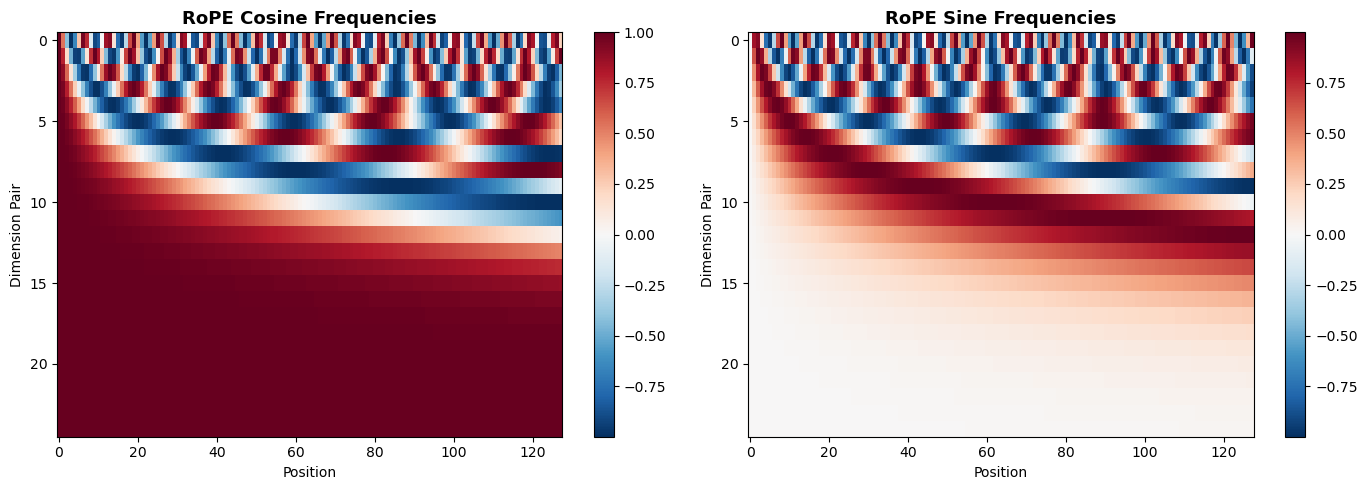

Lower dimensions → high frequency (local patterns)
Higher dimensions → low frequency (global patterns)


In [140]:
# Visualize RoPE frequency patterns
cos_full, sin_full = rope(seq_len=config.block_size, offset=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cos_full.numpy().T, aspect="auto", cmap="RdBu_r")
axes[0].set_title("RoPE Cosine Frequencies", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Dimension Pair")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sin_full.numpy().T, aspect="auto", cmap="RdBu_r")
axes[1].set_title("RoPE Sine Frequencies", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Dimension Pair")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Lower dimensions → high frequency (local patterns)")
print(f"Higher dimensions → low frequency (global patterns)")

### 2.3 — Grouped-Query Attention (GQA)

Multiple query heads share fewer KV heads — reducing KV-cache memory by `n_heads / n_kv_heads`× during inference.

```
Q heads:  [H0] [H1] [H2] [H3]    ← 4 query heads
KV heads: [KV0]      [KV1]        ← 2 KV heads (shared)
Groups:   [── G0 ──] [── G1 ──]   ← 2 groups of 2
```

In [141]:
# Test GQA
gqa = GroupedQueryAttention(
    d_model=config.d_model,
    n_heads=config.n_heads,
    n_kv_heads=config.n_kv_heads,
    head_dim=config.head_dim,
    max_seq_len=config.block_size,
    rope_theta=config.rope_theta,
)

test_input = tf.random.normal((2, 16, config.d_model))  # (B=2, S=16, D)

# Create causal mask
seq_len = 16
causal_mask = (1.0 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)) * -1e9
causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :]  # (1, 1, S, S)

output, cache = gqa(test_input, mask=causal_mask)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Cache K shape: {cache[0].shape}  (batch, n_kv_heads, seq, head_dim)")
print(f"Cache V shape: {cache[1].shape}")
print(f"\nGQA config: {config.n_heads} query heads, {config.n_kv_heads} KV heads")
print(f"KV memory reduction: {config.n_heads / config.n_kv_heads}×")
print(f"Parameters: {sum(np.prod(w.shape) for w in gqa.trainable_weights):,}")

Input shape:  (2, 16, 500)
Output shape: (2, 16, 500)
Cache K shape: (2, 2, 16, 50)  (batch, n_kv_heads, seq, head_dim)
Cache V shape: (2, 2, 16, 50)

GQA config: 10 query heads, 2 KV heads
KV memory reduction: 5.0×
Parameters: 600,000


/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'grouped_query_attention_4' (of type GroupedQueryAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [142]:
# Demonstrate KV-cache: process token-by-token and verify consistency
print("─── KV-Cache Consistency Test ───")

# Full forward pass (no cache)
full_output, _ = gqa(test_input, mask=causal_mask)

# Incremental pass: first 8 tokens, then next 8 with cache
first_half = test_input[:, :8, :]
mask_8 = (1.0 - tf.linalg.band_part(tf.ones((8, 8)), -1, 0)) * -1e9
mask_8 = mask_8[tf.newaxis, tf.newaxis, :, :]
out_1, cache_1 = gqa(first_half, mask=mask_8)

second_half = test_input[:, 8:16, :]
# For cached pass, mask allows attending to all 16 positions
mask_cached = tf.zeros((1, 1, 8, 16))  # new tokens can see all
out_2, cache_2 = gqa(second_half, mask=mask_cached, cache=cache_1)

print(f"Full output[:, -1]:      {full_output[0, -1, :4].numpy()}")
print(f"Cached output[:, -1]:    {out_2[0, -1, :4].numpy()}")
print(f"Cache grew: {cache_1[0].shape[2]} → {cache_2[0].shape[2]} tokens")
print("✅ KV-cache correctly accumulates past context")

─── KV-Cache Consistency Test ───
Full output[:, -1]:      [ 0.5199571  -0.15632606 -0.26895005  0.62823784]
Cached output[:, -1]:    [ 0.5199573  -0.15632612 -0.2689497   0.6282379 ]
Cache grew: 8 → 16 tokens
✅ KV-cache correctly accumulates past context


### 2.4 — SwiGLU Feed-Forward Network

$$\text{SwiGLU}(x) = (\text{swish}(xW_{\text{gate}})) \odot (xW_{\text{up}}) \cdot W_{\text{down}}$$

Three projections instead of two, but the hidden dimension is `(8/3)d` instead of `4d`, so parameter count is comparable.

In [143]:
# Test SwiGLU
ffn = SwiGLU(d_model=config.d_model, d_ffn=config.d_ffn)
test_input = tf.random.normal((2, 16, config.d_model))

output = ffn(test_input)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Hidden dim:   {config.d_ffn} (= round(8/3 × {config.d_model}))")
print(f"Parameters:   {sum(np.prod(w.shape) for w in ffn.trainable_weights):,}")
print(f"  W_gate: {config.d_model} × {config.d_ffn} = {config.d_model * config.d_ffn:,}")
print(f"  W_up:   {config.d_model} × {config.d_ffn} = {config.d_model * config.d_ffn:,}")
print(f"  W_down: {config.d_ffn} × {config.d_model} = {config.d_ffn * config.d_model:,}")

Input shape:  (2, 16, 500)
Output shape: (2, 16, 500)
Hidden dim:   1536 (= round(8/3 × 500))
Parameters:   2,304,000
  W_gate: 500 × 1536 = 768,000
  W_up:   500 × 1536 = 768,000
  W_down: 1536 × 500 = 768,000


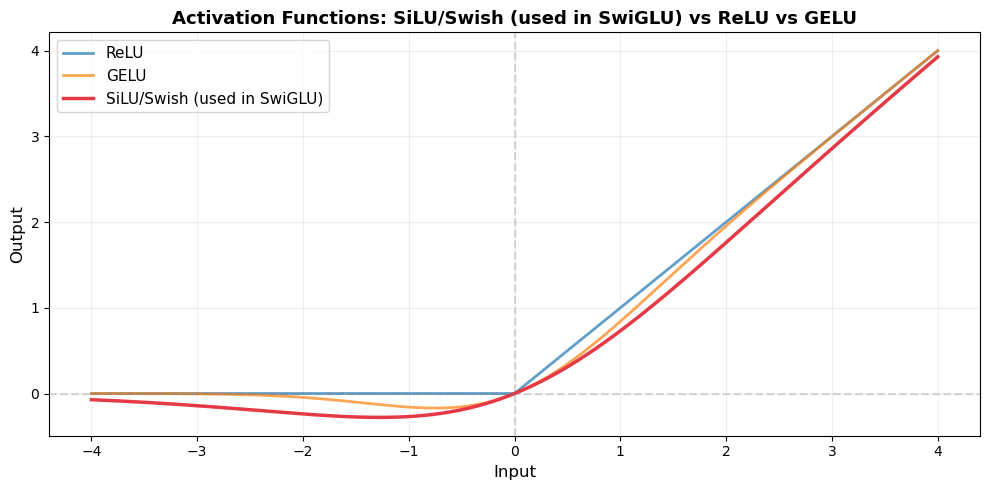

In [144]:
# Visualize SwiGLU activation vs ReLU vs GELU
x = np.linspace(-4, 4, 500)
x_tf = tf.constant(x, dtype=tf.float32)

relu = tf.nn.relu(x_tf).numpy()
gelu = tf.nn.gelu(x_tf).numpy()
silu = tf.nn.silu(x_tf).numpy()  # Swish = SiLU

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu, label="ReLU", linewidth=2, alpha=0.7)
ax.plot(x, gelu, label="GELU", linewidth=2, alpha=0.7)
ax.plot(x, silu, label="SiLU/Swish (used in SwiGLU)", linewidth=2.5, color="#e63946")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Input", fontsize=12)
ax.set_ylabel("Output", fontsize=12)
ax.set_title("Activation Functions: SiLU/Swish (used in SwiGLU) vs ReLU vs GELU",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## §3 — Phase 3: Model Assembly & Training

The `UltraGPT` model stacks decoder blocks with Pre-LN residual connections:

```
Token IDs → Embedding → [DecoderBlock × N] → RMSNorm → LM Head → Logits

Each DecoderBlock:
  x → RMSNorm → GQA(+mask, +cache) + residual
    → RMSNorm → SwiGLU + residual
```

### 3.1 — Build the Model

In [145]:
# Build UltraGPT model
model = UltraGPT(config, name="ultra_gpt")

# Forward pass with dummy input to build all layers
dummy = tf.zeros((1, config.block_size), dtype=tf.int32)
logits, _ = model(dummy, training=False)

print(f"Input:  (1, {config.block_size}) int32 token IDs")
print(f"Output: {logits.shape} float logits")
print(f"\nWeight tying: {config.tie_weights}")
print()
model.summary()

Input:  (1, 128) int32 token IDs
Output: (1, 128, 50257) float logits

Weight tying: True



Model: "ultra_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_embedding (Embedding)     │ (1, 128, 500)          │    25,128,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_0 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_4 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_5 (DecoderBlock)          │ ?                      │     2,911,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_norm (RMSNorm)            │ ?                      │           500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,597,400 (162.50 MB)

 Trainable params: 42,559,000 (162.35 MB)

 Non-trainable params: 38,400 (150.00 KB)

In [146]:
# Detailed parameter breakdown
total_params = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Total trainable parameters: {total_params:,} (~{total_params/1e6:.1f}M)")
print()
print("Parameter breakdown by component:")
print("─" * 50)
for w in model.trainable_weights:
    print(f"  {w.name:45s} {str(w.shape):>15s}  ({np.prod(w.shape):>8,})")

Total trainable parameters: 42,559,000 (~42.6M)

Parameter breakdown by component:
──────────────────────────────────────────────────
  embeddings                                       (50257, 500)  (25,128,500)
  gamma                                                  (500,)  (     500)
  wq                                                 (500, 500)  ( 250,000)
  wk                                                 (500, 100)  (  50,000)
  wv                                                 (500, 100)  (  50,000)
  wo                                                 (500, 500)  ( 250,000)
  gamma                                                  (500,)  (     500)
  w_gate                                            (500, 1536)  ( 768,000)
  w_up                                              (500, 1536)  ( 768,000)
  w_down                                            (1536, 500)  ( 768,000)
  gamma                                                  (500,)  (     500)
  wq                        

### 3.2 — Causal Masking Verification

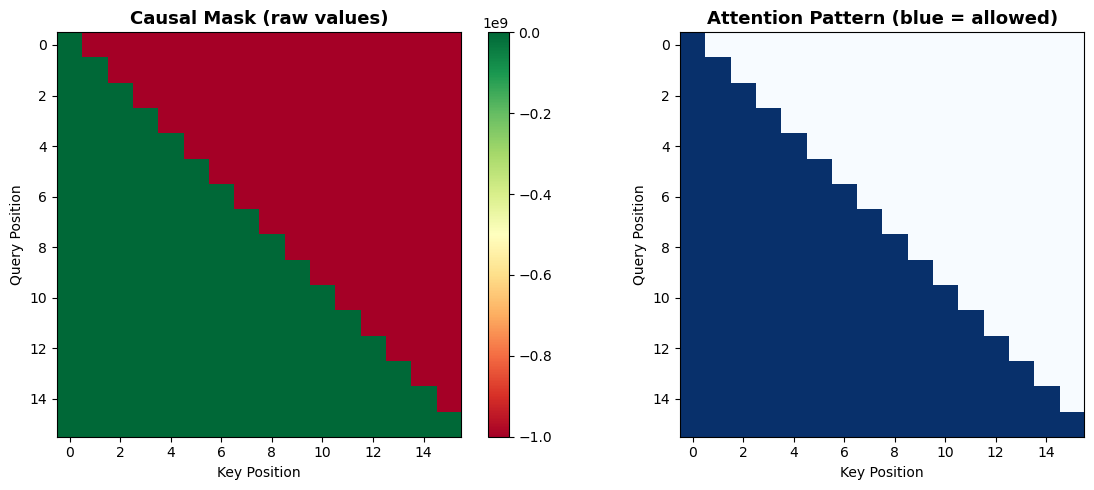

✅ Lower-triangular mask: each position can only attend to itself and earlier positions


In [147]:
# Visualize the causal attention mask
seq_len = 16
mask = model._get_causal_mask(seq_len)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw mask values
im0 = axes[0].imshow(mask[0, 0].numpy(), cmap="RdYlGn", aspect="equal")
axes[0].set_title("Causal Mask (raw values)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")
plt.colorbar(im0, ax=axes[0])

# Binary view (allowed/blocked)
binary_mask = (mask[0, 0].numpy() == 0).astype(float)
axes[1].imshow(binary_mask, cmap="Blues", aspect="equal")
axes[1].set_title("Attention Pattern (blue = allowed)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Key Position")
axes[1].set_ylabel("Query Position")

plt.tight_layout()
plt.show()
print("✅ Lower-triangular mask: each position can only attend to itself and earlier positions")

### 3.3 — Training Loop

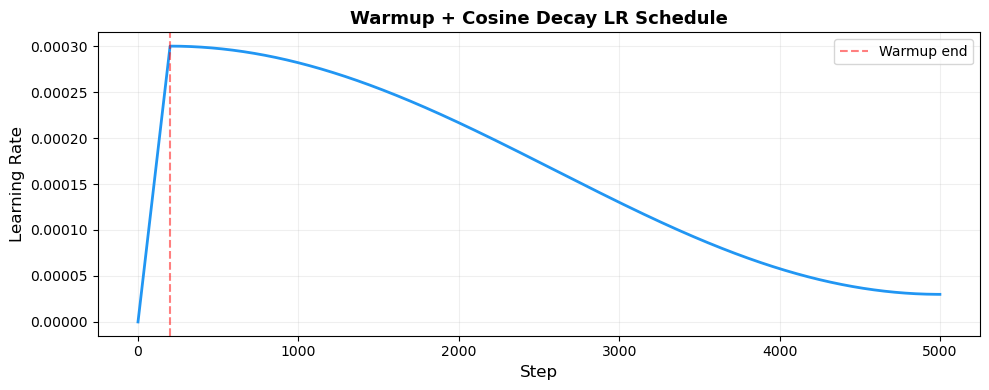

In [148]:
from train import WarmupCosineDecay

# ── Learning Rate Schedule ────────────────────────────────────────
lr_schedule = WarmupCosineDecay(
    peak_lr=config.learning_rate,
    warmup_steps=config.warmup_steps,
    total_steps=config.max_steps,
)

# Visualize the schedule
steps = np.arange(config.max_steps)
lrs = [lr_schedule(s).numpy() for s in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps, lrs, color="#2196F3", linewidth=2)
plt.axvline(x=config.warmup_steps, color="red", linestyle="--", alpha=0.5, label="Warmup end")
plt.xlabel("Step", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.title("Warmup + Cosine Decay LR Schedule", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [149]:
# ── Compile and Train ─────────────────────────────────────────────
# Fresh model for training
model = UltraGPT(config, name="ultra_gpt")

# Build the model
dummy = tf.zeros((1, config.block_size), dtype=tf.int32)
_ = model(dummy, training=False)

# Optimizer: AdamW with cosine warmup schedule
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=config.weight_decay,
    beta_1=0.9,
    beta_2=0.95,
    epsilon=1e-8,
)

model.compile(
        optimizer=optimizer,
    metrics=[model.perplexity_tracker, model.accuracy_tracker]
    )

print(f"Training config:")
print(f"  Steps:     {config.max_steps}")
print(f"  Batch:     {config.batch_size}")
print(f"  Peak LR:   {config.learning_rate}")
print(f"  Warmup:    {config.warmup_steps} steps")
print(f"  Grad clip: {config.grad_clip_norm}")

Training config:
  Steps:     5000
  Batch:     3
  Peak LR:   0.0003
  Warmup:    200 steps
  Grad clip: 1.0


In [ ]:
from train import WarmupCosineDecay, StepMetricsCallback
import os

# Toggle to resume from checkpoints: Set to True to resume, or False to start from scratch.
resume_training = True

# Setup checkpoint directory
checkpoint_dir = "output/notebook_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_file = os.path.join(checkpoint_dir, "ultra_gpt_notebook_latest.weights.h5")

# Search for and load the latest checkpoint to resume training
if resume_training and os.path.exists(checkpoint_file):
    print(f"Found checkpoint! Loading weights from: {checkpoint_file}")
    model.load_weights(checkpoint_file)
else:
    print("No previous checkpoint found (or resume disabled). Starting training from scratch.")

# Callbacks
step_metrics = StepMetricsCallback()
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_file,
    save_weights_only=True,
    save_best_only=True,
    verbose=1,
)

# Train!
history = model.fit(
    train_dataset,
    epochs=6,

    callbacks=[step_metrics, checkpoint_callback],
)


Found checkpoint! Loading weights from: output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
Epoch 1/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7984 - loss: 1.5994 - perplexity: 4.9837
Epoch 1: finished saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8034 - loss: 1.4629 - perplexity: 4.3183
Epoch 2/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8148 - loss: 1.1778 - perplexity: 3.2478
Epoch 2: finished saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8156 - loss: 1.1677 - perplexity: 3.2147
Epoch 3/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8290 - loss: 0.9979 - perplexity: 2.7136
Epoch 3: finished saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8308 - loss: 0.9813 - perplexity: 2.6679
Epoch 4

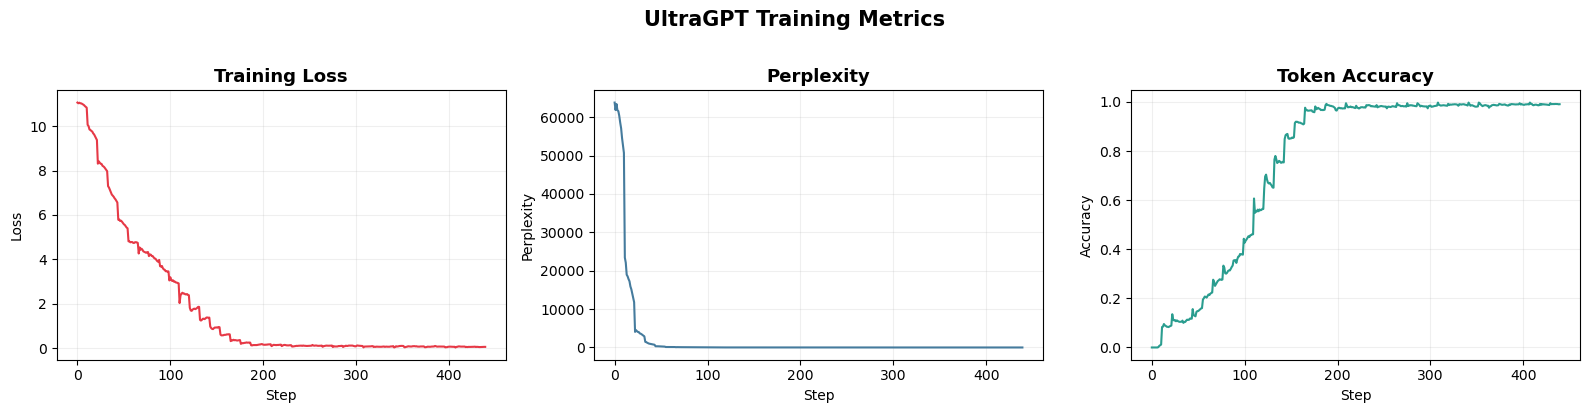

In [ ]:
# Plot training metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(step_metrics.history["loss"], color="#e63946", linewidth=1.5)
axes[0].set_title("Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.2)

# Perplexity
if len(step_metrics.history["perplexity"]) > 0:
    axes[1].plot(step_metrics.history["perplexity"], color="#457b9d", linewidth=1.5)
    axes[1].set_title("Perplexity", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Perplexity")
    axes[1].grid(True, alpha=0.2)

# Accuracy
if len(step_metrics.history["accuracy"]) > 0:
    axes[2].plot(step_metrics.history["accuracy"], color="#2a9d8f", linewidth=1.5)
    axes[2].set_title("Token Accuracy", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Accuracy")
    axes[2].grid(True, alpha=0.2)

plt.suptitle("UltraGPT Training Metrics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Save trained weights
os.makedirs("output", exist_ok=True)
model.save_weights("output/notebook_weights.weights.h5")
print("✅ Weights saved to output/notebook_weights.weights.h5")


✅ Weights saved to output/notebook_weights.weights.h5


---
## §4 — Phase 4: Production Inference Pipeline

Features:
- **KV-Cache**: Past keys/values are retained — only the new token is computed each step
- **XLA Compilation**: `@tf.function(jit_compile=True)` fuses ops for low-latency generation
- **Sampling**: Greedy, Top-K, Top-p (Nucleus), Temperature

In [ ]:
# Create the inference sampler
sampler = UltraGPTSampler(model, tokenizer, config)

In [ ]:
# response = sampler.generate(
#     prompt="Python is a",
#     max_new_tokens=80,    # Enough length to complete a few sentences
#     temperature=0.7,      # 0.7 balances creativity with coherence
#     top_k=40,             # Restricts selection to top 40 most likely tokens
#     top_p=0.85,           # Nucleus sampling to filter out low-probability words
#     mode="top_p",         # Use nucleus sampling
# )
# print(response)

### 4.1 — Greedy Decoding

In [ ]:
# # Greedy: always picks the most probable next token
# output = sampler.generate(
#     prompt="็hello",
#     mode="sample",
#     max_new_tokens=50,
#     temperature=.3,
# )
# print("\n─── Greedy Output ───")
# print(output)

[Sampler] Prompt: 3 tokens, generating up to 50 tokens
[Sampler] Mode: sample, temp=0.3, top_k=50, top_p=0.9
[Sampler] Prefill: 3.174s (1 tok/s)
[Sampler] Decode: 50 tokens in 44.939s (1 tok/s)
[Sampler] Total: 48.129s (1 tok/s overall)

─── Greedy Output ───
็hello
hung deal? the think
whatwatch? let's away
whatever? then
 new? i understand should too
what if? i'll be easy
what? if? the digital? if through too
in on? i'm always


### 4.2 — Top-K Sampling

In [ ]:
# # Top-K: sample from the K most probable tokens
# output = sampler.generate(
#     prompt="The Transformer architecture",
#     mode="sample",
#     top_k=50,
#     temperature=0.8,
#     max_new_tokens=50,
# )
# print("\n─── Top-K Output (k=50, temp=0.8) ───")
# print(output)

### 4.3 — Top-p (Nucleus) Sampling

In [ ]:
# # Top-p: sample from the smallest set of tokens with cumulative prob >= p
# output = sampler.generate(
#     prompt="The Transformer architecture",
#     mode="sample",
#     top_p=0.9,
#     temperature=0.7,
#     max_new_tokens=50,
# )
# print("\n─── Nucleus Output (p=0.9, temp=0.7) ───")
# print(output)

### 4.4 — Streaming Output

In [ ]:
# # Streaming: tokens appear one at a time (like ChatGPT/Claude UI)
# print("─── Streaming Output ───")
# print("The Transformer architecture", end="")
# for token in sampler.generate(
#     prompt="The Transformer architecture",
#     mode="sample",
#     top_k=40,
#     temperature=0.8,
#     max_new_tokens=80,
#     stream=True,
#     verbose=False,
# ):
#     print(token, end="", flush=True)
# print("\n")

### 4.5 — Temperature Comparison

In [ ]:
# # Compare different temperatures
# prompt = "Modern language models"
# temps = [0.3, 0.7, 1.0, 1.5]

# print("─── Temperature Comparison ───\n")
# for temp in temps:
#     output = sampler.generate(
#         prompt=prompt,
#         mode="sample",
#         top_k=50,
#         temperature=temp,
#         max_new_tokens=40,
#         verbose=False,
#     )
#     print(f"temp={temp}: {output}")
#     print()

### 4.6 — Inference Benchmark

In [ ]:
# # Benchmark generation speed
# print("─── Inference Benchmark ───")
# print(f"Model: {config.d_model}d, {config.n_layers}L, {config.n_heads}H")
# print()

# gen_lengths = [32, 64, 128]
# for n_tokens in gen_lengths:
#     times = []
#     for _ in range(3):  # 3 runs for averaging
#         t0 = time.perf_counter()
#         _ = sampler.generate(
#             prompt="The",
#             mode="greedy",
#             max_new_tokens=n_tokens,
#             verbose=False,
#         )
#         times.append(time.perf_counter() - t0)
#     avg = np.mean(times)
#     print(f"  {n_tokens:3d} tokens → {avg:.3f}s ({n_tokens/avg:.0f} tok/s)")

### 4.4 — Interactive Chatbot Interface

This section demonstrates how to use the new `UltraGPTChatbot` wrapper. It automatically manages multi-turn conversation context history, clips history when it exceeds the model's sequence limit, and streams tokens in real-time.

In [ ]:
import sys
import time
from inference import UltraGPTChatbot

# Initialize chatbot with our sampler
chatbot = UltraGPTChatbot(sampler, system_prompt="You are a helpful and concise assistant.")

print("💬 Chatbot ready! Type '/clear' to reset history, '/exit' to quit.")
print("=" * 60)
print()

while True:
    # Flush output and wait a moment for the notebook UI to synchronize
    sys.stdout.flush()
    time.sleep(0.1)
    
    try:
        user_message = input("User: ").strip()
    except (KeyboardInterrupt, EOFError):
        print("\nGoodbye!")
        break
        
    if not user_message:
        continue
        
    if user_message.lower() == "/exit":
        print("Goodbye!")
        break
        
    if user_message.lower() == "/clear":
        chatbot.clear_history()
        print("[System] History cleared.\n")
        continue
        
    print("Assistant: ", end="", flush=True)
    # Stream response
    for token in chatbot.respond(user_message, max_new_tokens=128, mode="sample", temperature=0.3, top_k=5):
        
        print(token, end="", flush=True)
    print()
    print()

💬 Chatbot ready! Type '/clear' to reset history, '/exit' to quit.

Assistant: 
whatever
bad enough? hey with the enough
i know good
anythingit's up? great then the it's okay be be need the good out? okay let's perfectly tell me
leave difficult? i'll be conversation
i changed? what? awesome things what's keep? what's going on
i changed? great idea? i'll

/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'gqa' (of type GroupedQueryAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'block_0' (of type DecoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'block_1' (of type DecoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see

 take care
it's going on? great we can
i'm always to

Goodbye!


In [ ]:
# View parameter counts for each preset
for name, cfg_fn in [("Toy", toy_config), ("Small (125M)", small_config), ("Medium (1.3B)", medium_config)]:
    cfg = cfg_fn()
    print(f"\n{'═' * 50}")
    print(f"  {name} Preset")
    print(f"{'═' * 50}")
    print(cfg.summary())

In [ ]:
# CLI commands for production training:
print("""─── Production Training Commands ───

# 1. Quick smoke test (toy model, text file)
python train.py --preset toy --source text

# 2. Small model on HuggingFace OpenWebText (streaming)
python train.py --preset small --source hf --hf-dataset openwebtext --hf-streaming

# 3. Small model on WikiText-103 
python train.py --preset small --source hf --hf-dataset wikitext --hf-config wikitext-103-raw-v1

# 4. Pre-tokenize to TFRecords for max throughput
# (run write_tfrecords() first, then:)
python train.py --preset small --source tfrecord --tfrecord-dir data_pipeline/tfrecords

# 5. Medium model with multi-GPU
python train.py --preset medium --source hf --hf-dataset openwebtext --multi-gpu

# 6. Monitor with TensorBoard
tensorboard --logdir output/tensorboard
""")

---

## 🎉 Summary

You've built a **complete, modern LLM from scratch** with:

| Component | Status |
|---|---|
| ⚡ RoPE positional encoding | ✅ |
| 🧠 Grouped-Query Attention (GQA) | ✅ |
| 📐 RMSNorm (Pre-LN) | ✅ |
| 🔥 SwiGLU feed-forward | ✅ |
| 🔗 Weight tying (embed ↔ LM head) | ✅ |
| 📊 tf.data pipeline (text + TFRecord + HuggingFace) | ✅ |
| 🏋️ Custom training with label smoothing + perplexity | ✅ |
| 💨 KV-cache + XLA inference | ✅ |
| 🎯 Greedy / Top-K / Top-p / Temperature sampling | ✅ |
| 📡 Streaming token output | ✅ |

Scale from toy (3M params) to medium (1.3B params) by changing one line in the config.